# Обучение моделей на основе деревьев

In [1]:
# Импорт библиотек
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (log_loss,  roc_auc_score, roc_curve, classification_report, confusion_matrix, f1_score, 
                           precision_score, recall_score, accuracy_score, precision_recall_curve)
import optuna
from optuna.samplers import TPESampler
from scipy.stats import randint
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


c:\Users\Пользователь\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
current_dir = Path.cwd()
file_path = current_dir.parent / "data" / "raw_data.csv"
data = pd.read_csv(file_path)

### Подготовка данных и деление на выборки

In [3]:
data.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,999,D-penicillamine,21532,M,N,N,N,N,2.3,316.0,3.35,172.0,1601.0,179.80,63.0,394.0,9.7,3.0,D
1,1,2574,Placebo,19237,F,N,N,N,N,0.9,364.0,3.54,63.0,1440.0,134.85,88.0,361.0,11.0,3.0,C
2,2,3428,Placebo,13727,F,N,Y,Y,Y,3.3,299.0,3.55,131.0,1029.0,119.35,50.0,199.0,11.7,4.0,D
3,3,2576,Placebo,18460,F,N,N,N,N,0.6,256.0,3.50,58.0,1653.0,71.30,96.0,269.0,10.7,3.0,C
4,4,788,Placebo,16658,F,N,Y,N,N,1.1,346.0,3.65,63.0,1181.0,125.55,96.0,298.0,10.6,4.0,C


In [4]:
# Убираем лишнее
data = data.drop(['id', 'N_Days', 'Sex'], axis=1)
data = data[data['Status'] != 'CL']

# Разделение на признаки и таргет
X = data.drop('Status', axis=1)
y = data['Status']

# Кодирование таргета
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f'\nНовые классы: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')

# Разделение на train и test со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('')
print(f'Размер тренировочных данных: {X_train.shape}')
print(f'Размер тестовых данных: {X_test.shape}')


Новые классы: {'C': np.int64(0), 'D': np.int64(1)}

Размер тренировочных данных: (6104, 16)
Размер тестовых данных: (1526, 16)


In [5]:
# Разделение признаков на категориальные и числовые
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Создаем трансформер для категориальных признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',
            drop='first'
        ), cat_cols)
    ],
    remainder='passthrough'  # числовые признаки проходят как есть
)

In [6]:
# Стратегия для кросс-валидации
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 1. Дерево решений (Decision Tree Classifier)

### 1.1 Baseline

In [7]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

Метрики на кросс-валидации


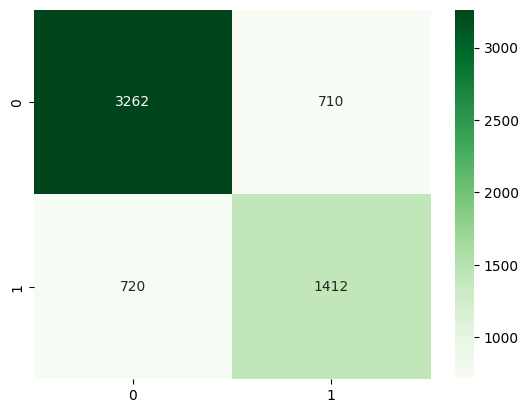

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      3972
           1       0.67      0.66      0.66      2132

    accuracy                           0.77      6104
   macro avg       0.74      0.74      0.74      6104
weighted avg       0.77      0.77      0.77      6104

Log-loss на кросс-валидации: 8.44
ROC-AUC на кросс-валидации: 0.74
CPU times: total: 797 ms
Wall time: 5.08 s


In [8]:
%%time
# Обучаем
tree_pipeline.fit(X_train, y_train)

# Оцениваем качество на кросс-валидации
y_pred_base_tree = cross_val_predict(
    tree_pipeline, X_train, y_train, cv=skf
)

print('Метрики на кросс-валидации')
sns.heatmap(confusion_matrix(y_train, y_pred_base_tree), annot=True, fmt='d',  cmap='Greens')
plt.show()
report_cv = classification_report(y_train, y_pred_base_tree)
print(report_cv)

# Получаем вероятности предсказаний для каждого фолда
y_pred_proba_cv = cross_val_predict(
    tree_pipeline, X_train, y_train, cv=skf, method='predict_proba', n_jobs=-1
)

# Вычисляем log-loss и Roc-Auc на всей кросс-валидации
cv_log_loss = log_loss(y_train, y_pred_proba_cv)
roc_auc_cv = roc_auc_score(y_train, y_pred_proba_cv[:, 1])
print(f"Log-loss на кросс-валидации: {cv_log_loss:.2f}")
print(f"ROC-AUC на кросс-валидации: {roc_auc_cv:.2f}")

Далее попробуем увеличить recall и f1 для класса 1, уменьшить log-loss и поднять roc-auc.

### 1.2 Гиперпараметры (GridSearchCV), балансировка классов, важность признаков, перебор порогового значения

In [9]:
tree_pipeline_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

Fitting 5 folds for each of 1800 candidates, totalling 9000 fits
Лучшие параметры модели: {'classifier__max_depth': 6, 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 2}

Оценка на кросс-валидации:


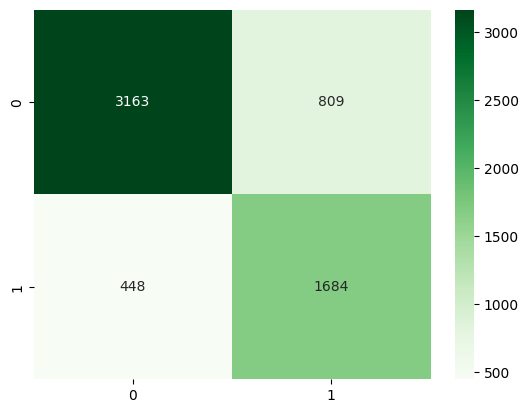

              precision    recall  f1-score   support

           0       0.88      0.80      0.83      3972
           1       0.68      0.79      0.73      2132

    accuracy                           0.79      6104
   macro avg       0.78      0.79      0.78      6104
weighted avg       0.81      0.79      0.80      6104

Log-loss на кросс-валидации: 0.59
ROC-AUC на кросс-валидации: 0.86
CPU times: total: 57.7 s
Wall time: 4min 16s


In [10]:
%%time
# Параметры для перебора
param_grid = {
    'classifier__max_depth': range(1, 21),
    'classifier__min_samples_split': range(2, 11),
    'classifier__min_samples_leaf': range(1, 11)
}

# Создаем GridSearchCV
tree_GS = GridSearchCV(
    estimator=tree_pipeline_balanced,
    param_grid=param_grid,
    scoring='recall_macro',
    cv=skf,
    n_jobs=-1,
    verbose=1
)

# Ищем гиперпараметры
tree_GS.fit(X_train, y_train)

# Лучшая модель
best_pipeline = tree_GS.best_estimator_

# Предсказания на кросс-валидации
y_pred_balanced = cross_val_predict(best_pipeline, X_train, y_train, cv=skf, n_jobs=-1)

print(f'Лучшие параметры модели: {tree_GS.best_params_}')
print('')
print('Оценка на кросс-валидации:')
sns.heatmap(confusion_matrix(y_train, y_pred_balanced), annot=True, fmt='d',  cmap='Greens')
plt.show()
report_cv = classification_report(y_train, y_pred_balanced)
print(report_cv)

# Получаем вероятности предсказаний для каждого фолда
y_pred_proba_balanced = cross_val_predict(
    best_pipeline, X_train, y_train, cv=skf, method='predict_proba', n_jobs=-1
)

# Вычисляем log-loss и Roc-Auc на всей кросс-валидации
log_loss_cv_balanced = log_loss(y_train, y_pred_proba_balanced)
roc_auc_cv_balanced = roc_auc_score(y_train, y_pred_proba_balanced[:, 1])
print(f"Log-loss на кросс-валидации: {log_loss_cv_balanced:.2f}")
print(f"ROC-AUC на кросс-валидации: {roc_auc_cv_balanced:.2f}")

#### 1.2.1. Feature importance

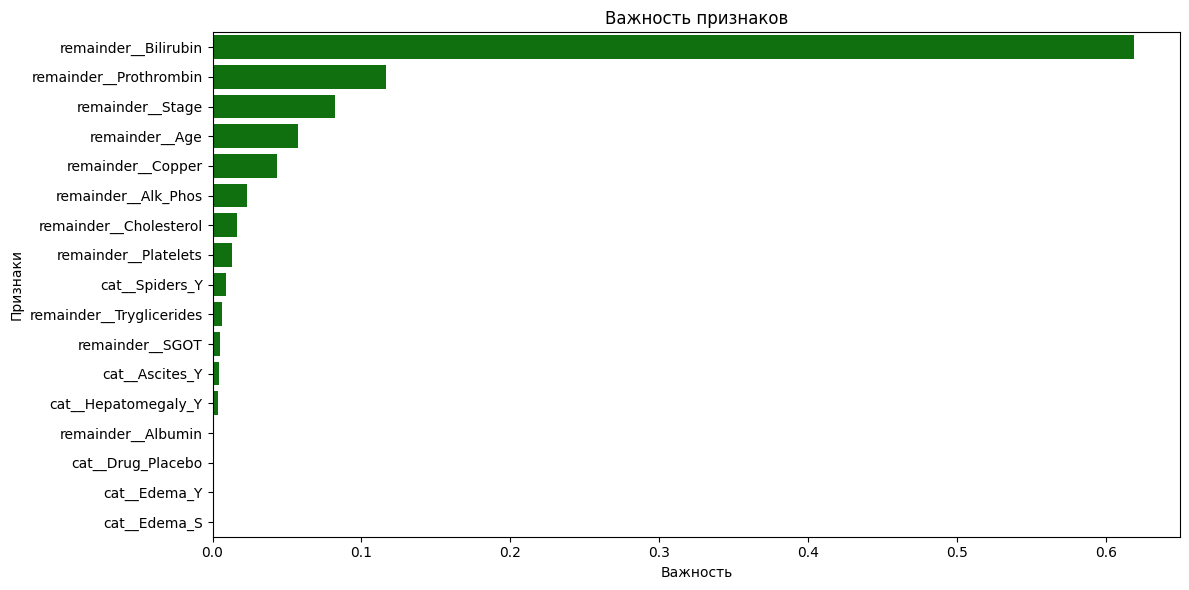

In [11]:
# Получаем классификатор из пайплайна
best_tree_balanced = best_pipeline.named_steps['classifier']
feature_importances = best_tree_balanced.feature_importances_

# Получаем препроцессор
preprocessor = best_pipeline.named_steps['preprocessor']

# Получаем имена признаков после трансформации
try:
    # Для sklearn >= 1.0
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    # Для старых версий или ручное получение
    feature_names = []
    
    # Трансформируем одну строку, чтобы узнать количество фичей
    X_sample = X_train.head(1)
    X_transformed = preprocessor.transform(X_sample)
    num_features = X_transformed.shape[1]
    feature_names = [f'feature_{i}' for i in range(num_features)]

# Создаем DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
top_n = min(20, len(importance_df))
sns.barplot(data=importance_df.head(top_n), 
            x='importance', 
            y='feature',
            color='green',
            orient='h')

plt.title(f'Важность признаков')
plt.xlabel('Важность')
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()

Оценка на кросс-валидации:


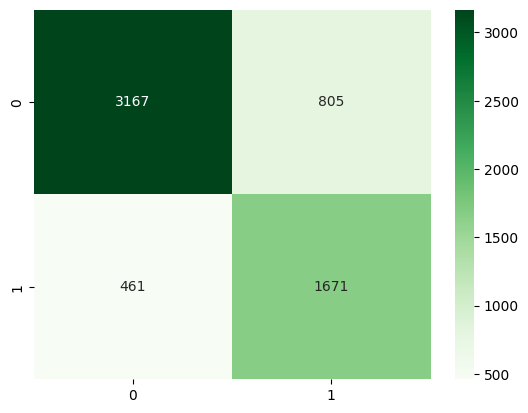

              precision    recall  f1-score   support

           0       0.87      0.80      0.83      3972
           1       0.67      0.78      0.73      2132

    accuracy                           0.79      6104
   macro avg       0.77      0.79      0.78      6104
weighted avg       0.80      0.79      0.80      6104

Log-loss на кросс-валидации: 0.57
ROC-AUC на кросс-валидации: 0.87


In [12]:
# Попробуем только первые 3 признака
cols = ['Bilirubin', 'Prothrombin', 'Stage']
X_train_selected = X_train[cols]

model_selected_features = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=6,
    min_samples_leaf=6,
    min_samples_split=2
)

# Предсказания на кросс-валидации
y_pred_selected = cross_val_predict(model_selected_features, X_train_selected, y_train, cv=skf, n_jobs=-1)

print('Оценка на кросс-валидации:')
sns.heatmap(confusion_matrix(y_train, y_pred_selected), annot=True, fmt='d',  cmap='Greens')
plt.show()
report_cv = classification_report(y_train, y_pred_selected)
print(report_cv)

# Получаем вероятности предсказаний для каждого фолда
y_pred_proba_selected = cross_val_predict(
    model_selected_features, X_train_selected, y_train, cv=skf, method='predict_proba', n_jobs=-1
)

# Вычисляем log-loss и Roc-Auc на всей кросс-валидации
log_loss_cv_sel = log_loss(y_train, y_pred_proba_selected)
roc_auc_cv_sel = roc_auc_score(y_train, y_pred_proba_selected[:, 1])
print(f"Log-loss на кросс-валидации: {log_loss_cv_sel:.2f}")
print(f"ROC-AUC на кросс-валидации: {roc_auc_cv_sel:.2f}")

**Выводы на этом этапе**: 

Получение луших гиперпараметров с помощью GridSearch и уменьшение признаков до первых трех по важности для модели пока дало наилучший результат. (Recall почти не меняется, log-loss немного снизилась, Roc-Auc повысился).

Оптимальный порог (метод F1-score): 0.468

Метрики для разных порогов:
    threshold  accuracy  precision  recall     f1    fpr
0        0.10     0.535      0.427   0.967  0.592  0.697
1        0.15     0.601      0.465   0.941  0.622  0.582
2        0.20     0.672      0.517   0.918  0.662  0.460
3        0.25     0.737      0.580   0.895  0.704  0.348
4        0.30     0.754      0.600   0.882  0.714  0.315
5        0.35     0.766      0.617   0.868  0.721  0.289
6        0.40     0.772      0.629   0.851  0.723  0.270
7        0.45     0.787      0.657   0.817  0.728  0.229
8        0.50     0.793      0.675   0.784  0.725  0.203
9        0.55     0.806      0.714   0.741  0.727  0.159
10       0.60     0.807      0.726   0.720  0.723  0.146
11       0.65     0.810      0.744   0.693  0.718  0.128
12       0.70     0.814      0.827   0.592  0.690  0.066
13       0.75     0.812      0.830   0.581  0.683  0.064
14       0.80     0.807      0.833   0.559  0.669  0.060
15       0.85    

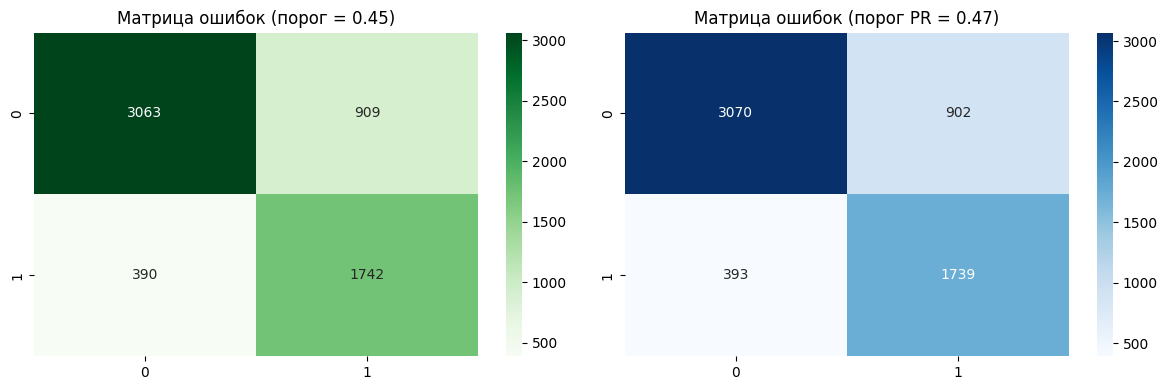


Классификационный отчет (порог из PR-кривой):
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      3972
           1       0.66      0.82      0.73      2132

    accuracy                           0.79      6104
   macro avg       0.77      0.79      0.78      6104
weighted avg       0.81      0.79      0.79      6104

СРАВНЕНИЕ С ПОРОГОМ ПО УМОЛЧАНИЮ (0.5)

Матрица ошибок (порог = 0.5):


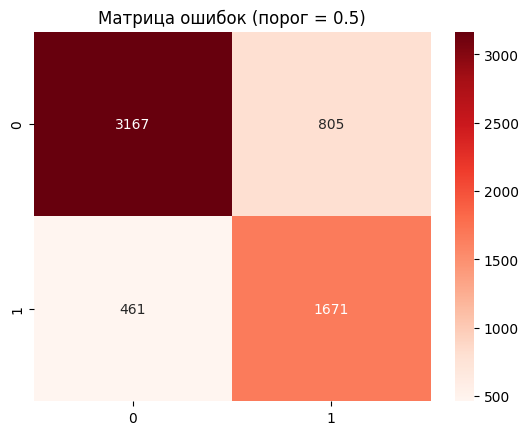


Классификационный отчет (порог = 0.5):
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      3972
           1       0.67      0.78      0.73      2132

    accuracy                           0.79      6104
   macro avg       0.77      0.79      0.78      6104
weighted avg       0.80      0.79      0.80      6104


Сравнение метрик для разных порогов:
  Метрика  Порог 0.5  Порог 0.45  Порог PR 0.47
 Accuracy   0.792595    0.787189       0.787844
Precision   0.674879    0.657111       0.658463
   Recall   0.783771    0.817073       0.815666
 F1-score   0.725260    0.728413       0.728682


In [13]:
cols = ['Bilirubin', 'Prothrombin', 'Stage']
X_train_selected = X_train[cols]

model_selected_features = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=6,
    min_samples_leaf=6,
    min_samples_split=2
)

# Получаем вероятности предсказаний для каждого фолда
y_pred_proba_selected = cross_val_predict(
    model_selected_features, 
    X_train_selected, 
    y_train, 
    cv=skf, 
    method='predict_proba', 
    n_jobs=-1
)

# Построение ROC-кривой и поиск оптимального порога
fpr, tpr, thresholds_roc = roc_curve(y_train, y_pred_proba_selected[:, 1])

# Вычисляем precision-recall кривую
precision, recall, thresholds_pr = precision_recall_curve(y_train, y_pred_proba_selected[:, 1])

# Порог, максимизирующий F1-score (используем precision и recall из кривой PR)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
optimal_idx_f1 = np.argmax(f1_scores)
optimal_threshold_f1 = thresholds_pr[optimal_idx_f1]

print(f"Оптимальный порог (метод F1-score): {optimal_threshold_f1:.3f}")

# Перебор порогов и оценка метрик
thresholds_to_test = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_pred_proba_selected[:, 1] >= threshold).astype(int)
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_train, y_pred_threshold),
        'precision': precision_score(y_train, y_pred_threshold, zero_division=0),
        'recall': recall_score(y_train, y_pred_threshold),
        'f1': f1_score(y_train, y_pred_threshold),
        'fpr': np.sum((y_pred_threshold == 1) & (y_train == 0)) / np.sum(y_train == 0)
    })

# Преобразуем в DataFrame для удобства
results_df = pd.DataFrame(results)
results_df = results_df.round(3)

print("\nМетрики для разных порогов:")
print(results_df.to_string())

# Находим лучший порог по F1-score из перебора
best_idx = results_df['f1'].idxmax()
best_threshold = results_df.loc[best_idx, 'threshold']
print(f"\nЛучший порог из перебора (по F1-score): {best_threshold:.3f}")

# Сравниваем с порогом из precision-recall кривой
print(f"Порог из PR-кривой (по F1-score): {optimal_threshold_f1:.3f}")

# Оценка с лучшим порогом (вы можете выбрать любой из двух)
print("ОЦЕНКА С ЛУЧШИМ ПОРОГОМ ИЗ ПЕРЕБОРА")
y_pred_best = (y_pred_proba_selected[:, 1] >= best_threshold).astype(int)

print('\nМатрица ошибок:')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_train, y_pred_best), annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title(f'Матрица ошибок (порог = {best_threshold:.2f})')

print('\nКлассификационный отчет:')
print(classification_report(y_train, y_pred_best))

# Оценка с порогом из PR-кривой
print("ОЦЕНКА С ПОРОГОМ ИЗ PR-КРИВОЙ")
y_pred_pr = (y_pred_proba_selected[:, 1] >= optimal_threshold_f1).astype(int)

sns.heatmap(confusion_matrix(y_train, y_pred_pr), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Матрица ошибок (порог PR = {optimal_threshold_f1:.2f})')
plt.tight_layout()
plt.show()

print('\nКлассификационный отчет (порог из PR-кривой):')
print(classification_report(y_train, y_pred_pr))

# Сравнение с порогом 0.5
print("СРАВНЕНИЕ С ПОРОГОМ ПО УМОЛЧАНИЮ (0.5)")
y_pred_default = (y_pred_proba_selected[:, 1] >= 0.5).astype(int)

print('\nМатрица ошибок (порог = 0.5):')
sns.heatmap(confusion_matrix(y_train, y_pred_default), annot=True, fmt='d', cmap='Reds')
plt.title('Матрица ошибок (порог = 0.5)')
plt.show()

print('\nКлассификационный отчет (порог = 0.5):')
print(classification_report(y_train, y_pred_default))

# Создание таблицы сравнения
comparison = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Порог 0.5': [
        accuracy_score(y_train, y_pred_default),
        precision_score(y_train, y_pred_default, zero_division=0),
        recall_score(y_train, y_pred_default),
        f1_score(y_train, y_pred_default)
    ],
    f'Порог {best_threshold:.2f}': [
        accuracy_score(y_train, y_pred_best),
        precision_score(y_train, y_pred_best, zero_division=0),
        recall_score(y_train, y_pred_best),
        f1_score(y_train, y_pred_best)
    ],
    f'Порог PR {optimal_threshold_f1:.2f}': [
        accuracy_score(y_train, y_pred_pr),
        precision_score(y_train, y_pred_pr, zero_division=0),
        recall_score(y_train, y_pred_pr),
        f1_score(y_train, y_pred_pr)
    ]
})

print("\nСравнение метрик для разных порогов:")
print(comparison.to_string(index=False))

Перебор порога не улучшает показатели.

## 2. Случайный лес (Random Forest Classifier)

### 2.1 Baseline

In [14]:
# Сделаем встроенную балансировку классов
forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

Метрики на кросс-валидации


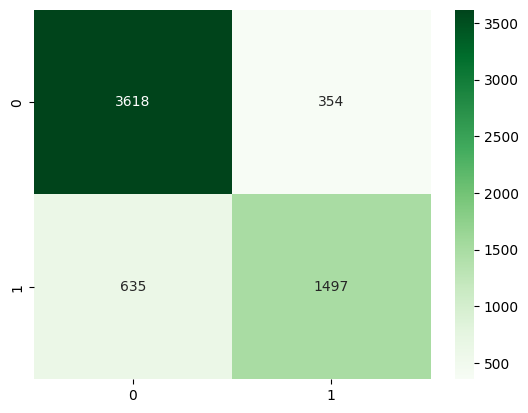

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      3972
           1       0.81      0.70      0.75      2132

    accuracy                           0.84      6104
   macro avg       0.83      0.81      0.82      6104
weighted avg       0.84      0.84      0.84      6104

Log-loss на кросс-валидации: 0.39
ROC-AUC на кросс-валидации: 0.90
CPU times: total: 10.8 s
Wall time: 14.2 s


In [15]:
%%time
# Обучаем
forest_pipeline.fit(X_train, y_train)

# Оцениваем качество на кросс-валидации
y_pred_base_f = cross_val_predict(
    forest_pipeline, X_train, y_train, cv=skf
)

print('Метрики на кросс-валидации')
sns.heatmap(confusion_matrix(y_train, y_pred_base_f), annot=True, fmt='d',  cmap='Greens')
plt.show()
report_cv = classification_report(y_train, y_pred_base_f)
print(report_cv)

# Получаем вероятности предсказаний для каждого фолда
y_pred_proba_cv = cross_val_predict(
    forest_pipeline, X_train, y_train, cv=skf, method='predict_proba', n_jobs=-1
)

# Вычисляем log-loss и Roc-Auc на всей кросс-валидации
cv_log_loss = log_loss(y_train, y_pred_proba_cv)
roc_auc_cv = roc_auc_score(y_train, y_pred_proba_cv[:, 1])
print(f"Log-loss на кросс-валидации: {cv_log_loss:.2f}")
print(f"ROC-AUC на кросс-валидации: {roc_auc_cv:.2f}")

Baseline модель со встроенной балансировкой классов уже дает неплохой результат. Попробуем сначала подобрать гиперпараметры.

### 2.2 Балансировка и гиперпараметры

[I 2025-12-19 15:46:46,678] A new study created in memory with name: rf_balanced_optimization
[I 2025-12-19 15:46:53,422] Trial 0 finished with value: 0.8719974591143737 and parameters: {'n_estimators': 400, 'max_depth': 48, 'min_samples_split': 23, 'min_samples_leaf': 12, 'max_features': 0.3, 'bootstrap': False, 'min_weight_fraction_leaf': 0.16648852816008436, 'max_leaf_nodes': 22}. Best is trial 0 with value: 0.8719974591143737.
[I 2025-12-19 15:47:02,805] Trial 1 finished with value: 0.8676712405620566 and parameters: {'n_estimators': 200, 'max_depth': 11, 'min_samples_split': 10, 'min_samples_leaf': 11, 'max_features': None, 'bootstrap': False, 'min_weight_fraction_leaf': 0.03993475643167195, 'max_leaf_nodes': 73}. Best is trial 0 with value: 0.8719974591143737.
[I 2025-12-19 15:47:28,352] Trial 2 finished with value: 0.8798793520705515 and parameters: {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True, 'min


Лучший trial:
Номер: 22
ROC-AUC: 0.8976

 Лучшие параметры Random Forest (class_weight='balanced'):
  • n_estimators: 150
  • max_depth: 28
  • min_samples_split: 6
  • min_samples_leaf: 3
  • max_features: log2
  • bootstrap: False
  • min_weight_fraction_leaf: 0.002534397529542219
  • max_leaf_nodes: 230
СОЗДАНИЕ ЛУЧШЕЙ МОДЕЛИ

 Параметры лучшей модели:
  n_estimators: 150
  max_depth: 28
  min_samples_split: 6
  min_samples_leaf: 3
  max_features: log2
  bootstrap: False
  criterion: gini
  min_weight_fraction_leaf: 0.002534397529542219
  max_leaf_nodes: 230
  class_weight: balanced
  random_state: 42
  n_jobs: -1

 Обучение лучшей модели на тренировочных данных...
ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ НА КРОСС-ВАЛИДАЦИИ

 Основные метрики:
ROC-AUC: 0.9016
Log-loss: 0.3890

CONFUSION MATRIX:


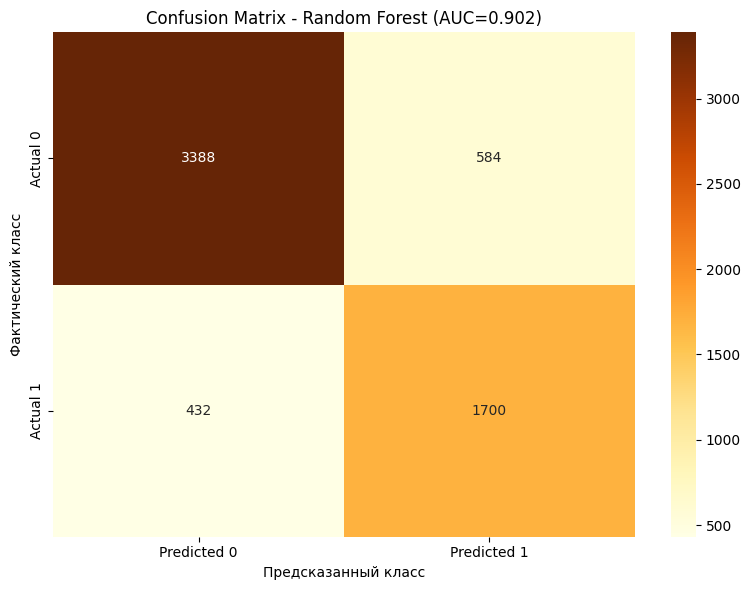


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      3972
           1       0.74      0.80      0.77      2132

    accuracy                           0.83      6104
   macro avg       0.82      0.83      0.82      6104
weighted avg       0.84      0.83      0.83      6104



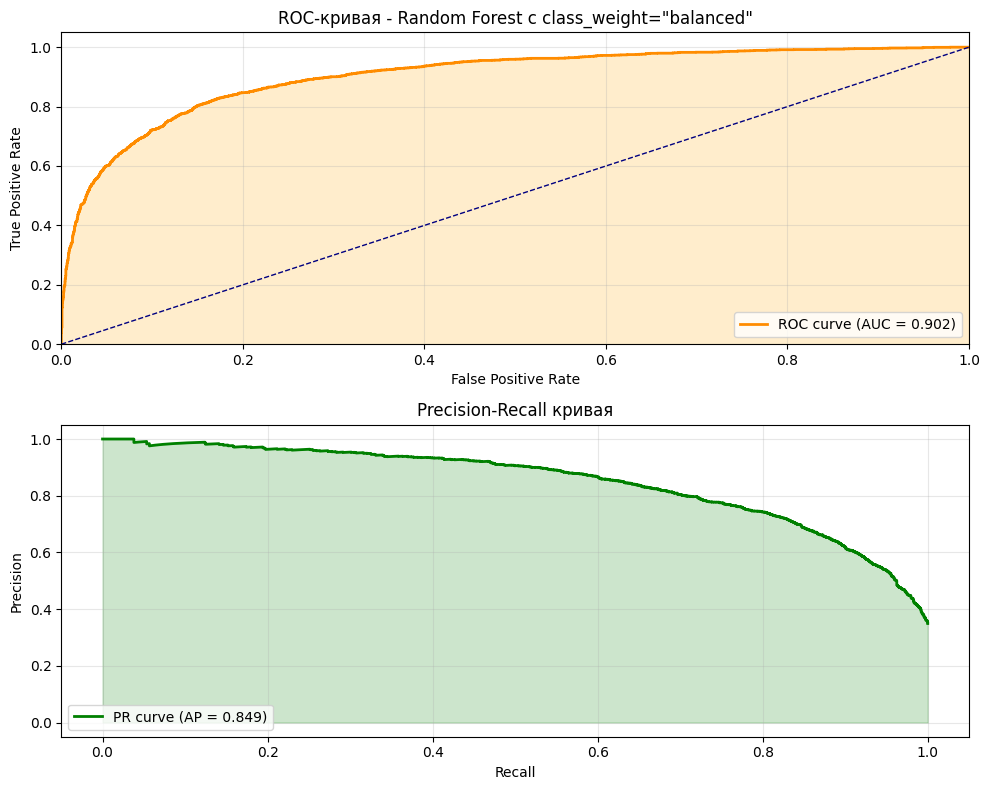

ВАЖНОСТЬ ПРИЗНАКОВ


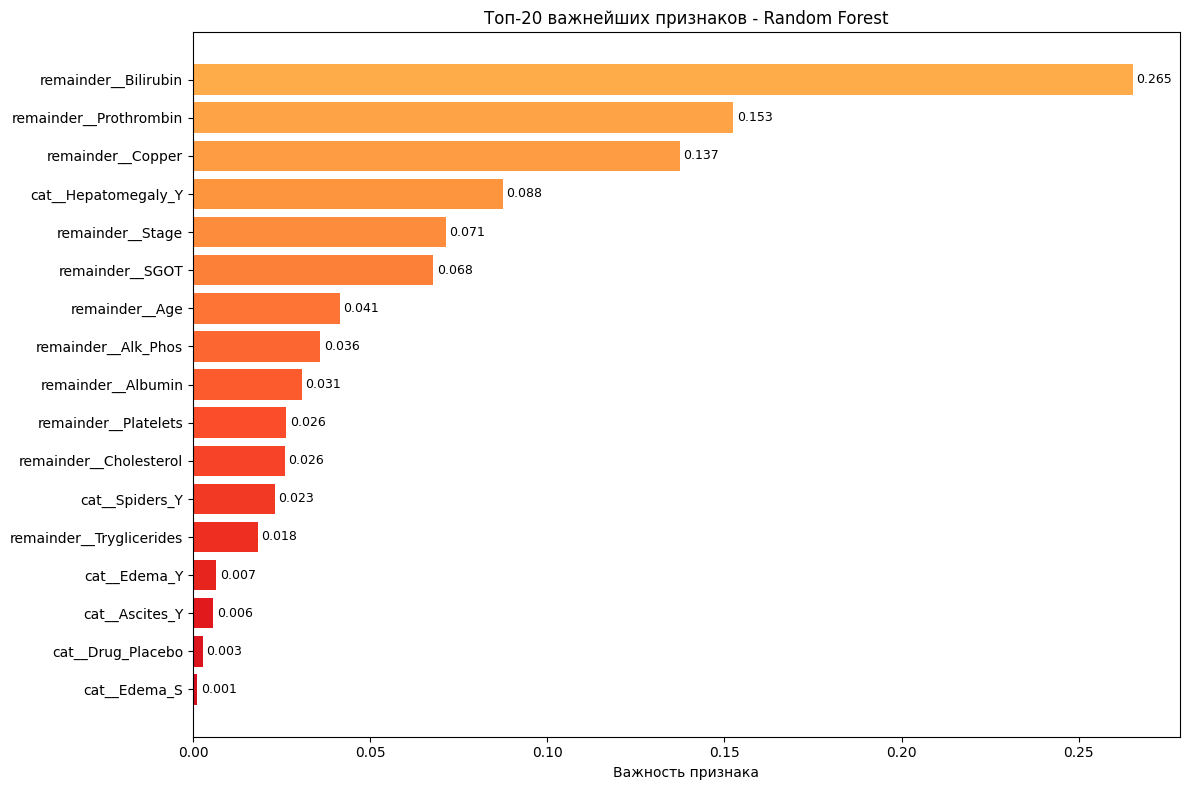

In [16]:
def objective(trial):
    # Параметры Random Forest
    rf_params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None, 0.3, 0.5, 0.7]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'min_weight_fraction_leaf': trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.2),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 500, log=True),
        'class_weight': 'balanced',  # Фиксированный параметр для балансировки классов
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Создаем пайплайн с текущими параметрами
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(**rf_params))
    ])
    
    # Оцениваем модель на кросс-валидации
    try:
        # Используем roc-auc как метрику
        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=skf,
            scoring='roc_auc',
            n_jobs=1,
            error_score='raise'
        )
        
        # Средний ROC-AUC
        roc_auc_mean = np.mean(scores)
        
        # Сохраняем информацию о trial
        trial.set_user_attr('std', float(np.std(scores)))
        trial.set_user_attr('min_score', float(np.min(scores)))
        trial.set_user_attr('max_score', float(np.max(scores)))
        trial.set_user_attr('cv_scores', scores.tolist())
        
        # Можно добавить penalty за сложность модели
        complexity_penalty = 0.00001 * rf_params['n_estimators'] + 0.0001 * rf_params['max_depth']
        return roc_auc_mean - complexity_penalty
        
    except Exception as e:
        # Если возникает ошибка, возвращаем плохой score
        print(f"Trial {trial.number} failed: {str(e)[:100]}")
        trial.set_user_attr('failed', True)
        trial.set_user_attr('error', str(e)[:200])
        return 0.0

# Создаем study
study = optuna.create_study(
    direction='maximize',  # максимизируем ROC-AUC
    sampler=TPESampler(seed=42),
    study_name='rf_balanced_optimization'
)

# Запускаем оптимизацию
study.optimize(
    objective,
    n_trials=60,  # количество trials
    n_jobs=1
)

# Выводим результаты
print(f"\nЛучший trial:")
print(f"Номер: {study.best_trial.number}")
print(f"ROC-AUC: {study.best_trial.value:.4f}")

print("\n Лучшие параметры Random Forest (class_weight='balanced'):")
best_params = study.best_trial.params
for key, value in best_params.items():
    print(f"  • {key}: {value}")

# Создаем лучшую модель с найденными параметрами
print("СОЗДАНИЕ ЛУЧШЕЙ МОДЕЛИ")

# Преобразуем параметры обратно в формат для RandomForest
rf_best_params = {
    'n_estimators': best_params.get('n_estimators', 100),
    'max_depth': best_params.get('max_depth', None),
    'min_samples_split': best_params.get('min_samples_split', 2),
    'min_samples_leaf': best_params.get('min_samples_leaf', 1),
    'max_features': best_params.get('max_features', 'sqrt'),
    'bootstrap': best_params.get('bootstrap', True),
    'criterion': best_params.get('criterion', 'gini'),
    'min_weight_fraction_leaf': best_params.get('min_weight_fraction_leaf', 0.0),
    'max_leaf_nodes': best_params.get('max_leaf_nodes', None),
    'class_weight': 'balanced',  # Фиксированный параметр
    'random_state': 42,
    'n_jobs': -1
}

print("\n Параметры лучшей модели:")
for key, value in rf_best_params.items():
    print(f"  {key}: {value}")

# Создаем и обучаем лучшую модель
best_rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(**rf_best_params))
])

# Обучаем на всех данных
print("\n Обучение лучшей модели на тренировочных данных...")
best_rf_model.fit(X_train, y_train)

# Оценка модели на кросс-валидации
print("ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ НА КРОСС-ВАЛИДАЦИИ")

# Получаем вероятности и предсказания на кросс-валидации
y_pred_proba_rf = cross_val_predict(best_rf_model, X_train, y_train, 
    cv=skf, method='predict_proba', n_jobs=-1
)
y_pred_rf = cross_val_predict(best_rf_model, X_train, y_train, cv=skf, n_jobs=-1)

# Вычисляем метрики
roc_auc_rf = roc_auc_score(y_train, y_pred_proba_rf[:, 1])
log_loss_rf = log_loss(y_train, y_pred_proba_rf)

print(f"\n Основные метрики:")
print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(f"Log-loss: {log_loss_rf:.4f}")

# Confusion matrix
print("\nCONFUSION MATRIX:")
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_train, y_pred_rf)
sns.heatmap(
    cm, 
    annot=True, fmt='d', cmap='YlOrBr',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title(f'Confusion Matrix - Random Forest (AUC={roc_auc_rf:.3f})')
plt.ylabel('Фактический класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# Classification report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_train, y_pred_rf))

# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba_rf[:, 1])
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.2, color='orange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая - Random Forest с class_weight="balanced"')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Precision-Recall кривая (важно для несбалансированных данных)
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_train, y_pred_proba_rf[:, 1])
avg_precision = average_precision_score(y_train, y_pred_proba_rf[:, 1])

plt.subplot(2, 1, 2)
plt.plot(recall, precision, color='green', lw=2, 
         label=f'PR curve (AP = {avg_precision:.3f})')
plt.fill_between(recall, precision, alpha=0.2, color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Важность признаков
print("ВАЖНОСТЬ ПРИЗНАКОВ")

# Получаем названия признаков после препроцессинга
if hasattr(preprocessor, 'get_feature_names_out'):
    feature_names = preprocessor.get_feature_names_out()
else:
    # Альтернативный способ
    feature_names = [f'feature_{i}' for i in range(best_rf_model.named_steps['classifier'].n_features_in_)]
    
# Получаем важность признаков
feature_importances = best_rf_model.named_steps['classifier'].feature_importances_
    
# Создаем DataFrame для сортировки
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)
    
# Топ-20 признаков
top_features = feature_importance_df.head(20)
   
# Визуализация
plt.figure(figsize=(12, 8))
colors = plt.cm.YlOrRd(np.linspace(0.4, 0.8, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Важность признака')
plt.title('Топ-20 важнейших признаков - Random Forest')
plt.gca().invert_yaxis()
    
# Добавляем значения
for i, (_, row) in enumerate(top_features.iterrows()):
    plt.text(row['importance'] + 0.001, i, f'{row["importance"]:.3f}', 
            va='center', fontsize=9)
    
plt.tight_layout()
plt.show()

[I 2025-12-19 15:54:43,545] A new study created in memory with name: smote_rf_optimization
[I 2025-12-19 15:54:58,471] Trial 0 finished with value: 0.9035439627415803 and parameters: {'smote_sampling_strategy': 0.5621780831931538, 'smote_k_neighbors': 10, 'rf_n_estimators': 380, 'rf_max_depth': 19, 'rf_min_samples_split': 4, 'rf_min_samples_leaf': 2, 'rf_max_features': 'log2', 'rf_bootstrap': True}. Best is trial 0 with value: 0.9035439627415803.
[I 2025-12-19 15:55:03,300] Trial 1 finished with value: 0.8980810810834491 and parameters: {'smote_sampling_strategy': 0.978936896513396, 'smote_k_neighbors': 9, 'rf_n_estimators': 145, 'rf_max_depth': 8, 'rf_min_samples_split': 5, 'rf_min_samples_leaf': 4, 'rf_max_features': 'sqrt', 'rf_bootstrap': True}. Best is trial 0 with value: 0.9035439627415803.
[I 2025-12-19 15:55:03,336] Trial 2 finished with value: 0.0 and parameters: {'smote_sampling_strategy': 0.5045012539746527, 'smote_k_neighbors': 5, 'rf_n_estimators': 255, 'rf_max_depth': 24,

Trial 2 failed: The specified ratio required to remove samples from the minority class while trying to generate new 


[I 2025-12-19 15:55:59,431] Trial 3 finished with value: 0.8271422660941006 and parameters: {'smote_sampling_strategy': 0.9642198760773333, 'smote_k_neighbors': 10, 'rf_n_estimators': 414, 'rf_max_depth': 11, 'rf_min_samples_split': 3, 'rf_min_samples_leaf': 7, 'rf_max_features': None, 'rf_bootstrap': False}. Best is trial 0 with value: 0.9035439627415803.
[I 2025-12-19 15:55:59,487] Trial 4 finished with value: 0.0 and parameters: {'smote_sampling_strategy': 0.48114598712001183, 'smote_k_neighbors': 8, 'rf_n_estimators': 190, 'rf_max_depth': 17, 'rf_min_samples_split': 12, 'rf_min_samples_leaf': 2, 'rf_max_features': 'sqrt', 'rf_bootstrap': True}. Best is trial 0 with value: 0.9035439627415803.


Trial 4 failed: The specified ratio required to remove samples from the minority class while trying to generate new 


[I 2025-12-19 15:56:04,322] Trial 5 finished with value: 0.8864713423899124 and parameters: {'smote_sampling_strategy': 0.9453119645161818, 'smote_k_neighbors': 3, 'rf_n_estimators': 138, 'rf_max_depth': 4, 'rf_min_samples_split': 8, 'rf_min_samples_leaf': 4, 'rf_max_features': 'log2', 'rf_bootstrap': False}. Best is trial 0 with value: 0.9035439627415803.
[I 2025-12-19 15:56:04,387] Trial 6 finished with value: 0.0 and parameters: {'smote_sampling_strategy': 0.3986469574823338, 'smote_k_neighbors': 9, 'rf_n_estimators': 83, 'rf_max_depth': 30, 'rf_min_samples_split': 16, 'rf_min_samples_leaf': 2, 'rf_max_features': 'log2', 'rf_bootstrap': False}. Best is trial 0 with value: 0.9035439627415803.
[I 2025-12-19 15:56:04,457] Trial 7 finished with value: 0.0 and parameters: {'smote_sampling_strategy': 0.35183125621386324, 'smote_k_neighbors': 5, 'rf_n_estimators': 102, 'rf_max_depth': 27, 'rf_min_samples_split': 13, 'rf_min_samples_leaf': 4, 'rf_max_features': None, 'rf_bootstrap': True}. 

...

Trial 39 failed: The specified ratio required to remove samples from the minority class while trying to generate new 
Trial 40 failed: The specified ratio required to remove samples from the minority class while trying to generate new 


[I 2025-12-19 16:00:57,237] Trial 41 finished with value: 0.9040043419620138 and parameters: {'smote_sampling_strategy': 0.5604912480705194, 'smote_k_neighbors': 9, 'rf_n_estimators': 439, 'rf_max_depth': 16, 'rf_min_samples_split': 6, 'rf_min_samples_leaf': 3, 'rf_max_features': 'log2', 'rf_bootstrap': True}. Best is trial 34 with value: 0.9045530375246784.
[I 2025-12-19 16:01:10,754] Trial 42 finished with value: 0.903807363556252 and parameters: {'smote_sampling_strategy': 0.6221830725239293, 'smote_k_neighbors': 9, 'rf_n_estimators': 406, 'rf_max_depth': 13, 'rf_min_samples_split': 9, 'rf_min_samples_leaf': 4, 'rf_max_features': 'log2', 'rf_bootstrap': True}. Best is trial 34 with value: 0.9045530375246784.
[I 2025-12-19 16:01:10,829] Trial 43 finished with value: 0.0 and parameters: {'smote_sampling_strategy': 0.4777113429782946, 'smote_k_neighbors': 8, 'rf_n_estimators': 474, 'rf_max_depth': 17, 'rf_min_samples_split': 2, 'rf_min_samples_leaf': 3, 'rf_max_features': 'log2', 'rf_b

Trial 43 failed: The specified ratio required to remove samples from the minority class while trying to generate new 
Trial 44 failed: The specified ratio required to remove samples from the minority class while trying to generate new 


[I 2025-12-19 16:01:25,080] Trial 45 finished with value: 0.9044377672902092 and parameters: {'smote_sampling_strategy': 0.5618936670243296, 'smote_k_neighbors': 10, 'rf_n_estimators': 431, 'rf_max_depth': 15, 'rf_min_samples_split': 7, 'rf_min_samples_leaf': 2, 'rf_max_features': 'log2', 'rf_bootstrap': True}. Best is trial 34 with value: 0.9045530375246784.
[I 2025-12-19 16:01:35,469] Trial 46 finished with value: 0.903869742861905 and parameters: {'smote_sampling_strategy': 0.5493175698930993, 'smote_k_neighbors': 10, 'rf_n_estimators': 354, 'rf_max_depth': 10, 'rf_min_samples_split': 5, 'rf_min_samples_leaf': 1, 'rf_max_features': 'log2', 'rf_bootstrap': True}. Best is trial 34 with value: 0.9045530375246784.
[I 2025-12-19 16:01:49,795] Trial 47 finished with value: 0.9040850390274157 and parameters: {'smote_sampling_strategy': 0.609654065148809, 'smote_k_neighbors': 4, 'rf_n_estimators': 396, 'rf_max_depth': 13, 'rf_min_samples_split': 4, 'rf_min_samples_leaf': 2, 'rf_max_features

Trial 48 failed: The specified ratio required to remove samples from the minority class while trying to generate new 
Trial 49 failed: The specified ratio required to remove samples from the minority class while trying to generate new 

Лучший trial:
Номер: 34
ROC-AUC: 0.9046

Лучшие параметры:

SMOTE:
  • sampling_strategy: 0.5405508300127206
  • k_neighbors: 8

Random Forest:
  • n_estimators: 500
  • max_depth: 12
  • min_samples_split: 5
  • min_samples_leaf: 3
  • max_features: log2
  • bootstrap: True
ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ OPTUNA НА КРОСС-ВАЛИДАЦИИ

Основные метрики:
ROC-AUC: 0.9042
Log-loss: 0.3687

CONFUSION MATRIX:


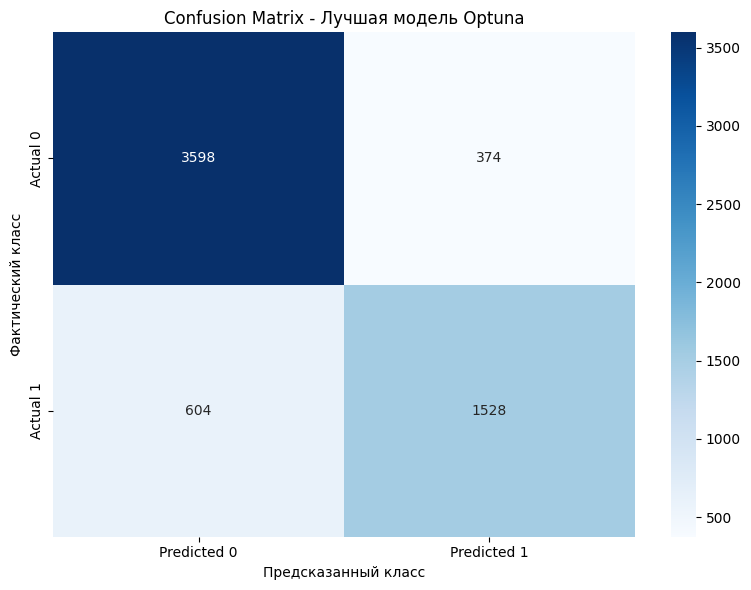


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      3972
           1       0.80      0.72      0.76      2132

    accuracy                           0.84      6104
   macro avg       0.83      0.81      0.82      6104
weighted avg       0.84      0.84      0.84      6104



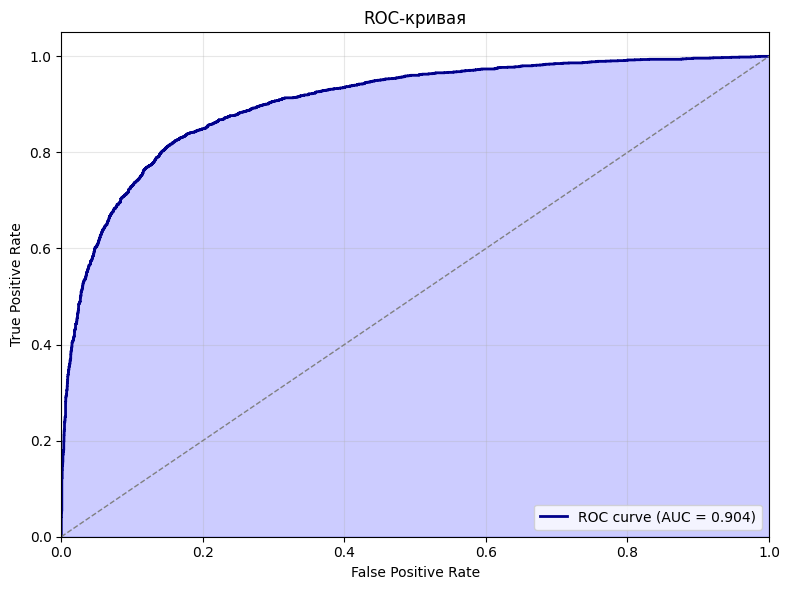

In [17]:
def objective(trial):
    # Параметры SMOTE
    smote_params = {
        'sampling_strategy': trial.suggest_float('smote_sampling_strategy', 0.3, 1.0),
        'k_neighbors': trial.suggest_int('smote_k_neighbors', 3, 10),
        'random_state': 42
    }
    
    # Параметры Random Forest
    rf_params = {
        'n_estimators': trial.suggest_int('rf_n_estimators', 50, 500),
        'max_depth': trial.suggest_int('rf_max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('rf_min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('rf_min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('rf_bootstrap', [True, False]),
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Создаем пайплайн с текущими параметрами
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(**smote_params)),
        ('classifier', RandomForestClassifier(**rf_params))
    ])
    
    # Оцениваем модель на кросс-валидации
    try:
        # Используем roc-auc как метрику
        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=skf,
            scoring='roc_auc',
            n_jobs=1,  # Важно: для Optuna используем n_jobs=1
            error_score='raise'
        )
        
        # Средний ROC-AUC
        roc_auc_mean = np.mean(scores)
        
        # Сохраняем информацию о trial
        trial.set_user_attr('std', float(np.std(scores)))
        trial.set_user_attr('min_score', float(np.min(scores)))
        trial.set_user_attr('max_score', float(np.max(scores)))
        trial.set_user_attr('cv_scores', scores.tolist())
        
        return roc_auc_mean
        
    except Exception as e:
        # Если возникает ошибка, возвращаем плохой score
        print(f"Trial {trial.number} failed: {str(e)[:100]}")
        trial.set_user_attr('failed', True)
        trial.set_user_attr('error', str(e)[:200])
        return 0.0

# Создаем study
study = optuna.create_study(
    direction='maximize',  # максимизируем ROC-AUC
    sampler=TPESampler(seed=42),
    study_name='smote_rf_optimization'
)

# Запускаем оптимизацию
study.optimize(
    objective,
    n_trials=50,
    n_jobs=1
)

# Выводим результаты
print(f"\nЛучший trial:")
print(f"Номер: {study.best_trial.number}")
print(f"ROC-AUC: {study.best_trial.value:.4f}")

print("\nЛучшие параметры:")
best_params = study.best_trial.params

print("\nSMOTE:")
for key, value in best_params.items():
    if key.startswith('smote_'):
        print(f"  • {key[6:]}: {value}")

print("\nRandom Forest:")
for key, value in best_params.items():
    if key.startswith('rf_'):
        print(f"  • {key[3:]}: {value}")

# Преобразуем параметры обратно в формат для пайплайна
smote_best_params = {
    'sampling_strategy': best_params['smote_sampling_strategy'],
    'k_neighbors': best_params['smote_k_neighbors'],
    'random_state': 42
}

rf_best_params = {
    'n_estimators': best_params['rf_n_estimators'],
    'max_depth': best_params['rf_max_depth'],
    'min_samples_split': best_params['rf_min_samples_split'],
    'min_samples_leaf': best_params['rf_min_samples_leaf'],
    'max_features': best_params['rf_max_features'],
    'bootstrap': best_params['rf_bootstrap'],
    'random_state': 42,
    'n_jobs': -1
}

# Создаем и обучаем лучшую модель
best_smote_model_optuna = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(**smote_best_params)),
    ('classifier', RandomForestClassifier(**rf_best_params))
])

# Обучаем на всех данных
best_smote_model_optuna.fit(X_train, y_train)

# Оценка модели на кросс-валидации
print("ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ OPTUNA НА КРОСС-ВАЛИДАЦИИ")

# Получаем вероятности
y_pred_proba_optuna = cross_val_predict(
    best_smote_model_optuna, X_train, y_train, 
    cv=skf, method='predict_proba', n_jobs=-1
)

# Получаем предсказания классов
y_pred_optuna = cross_val_predict(
    best_smote_model_optuna, X_train, y_train, 
    cv=skf, n_jobs=-1
)

# Вычисляем метрики
roc_auc_optuna = roc_auc_score(y_train, y_pred_proba_optuna[:, 1])
log_loss_optuna = log_loss(y_train, y_pred_proba_optuna)

print(f"\nОсновные метрики:")
print(f"ROC-AUC: {roc_auc_optuna:.4f}")
print(f"Log-loss: {log_loss_optuna:.4f}")

# Confusion matrix
print("\nCONFUSION MATRIX:")
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_train, y_pred_optuna), 
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Confusion Matrix - Лучшая модель Optuna')
plt.ylabel('Фактический класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# Classification report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_train, y_pred_optuna))

# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba_optuna[:, 1])
roc_auc = roc_auc_score(y_train, y_pred_proba_optuna[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Попробуем самые важные для модели признаки
cols = ['Bilirubin', 'Copper', 'Prothrombin']
X_train_selected = X_train[cols]


In [19]:
# Создание объекта SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto')

# Применение SMOTE только к тренировочным данным
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

Оценка на кросс-валидации:


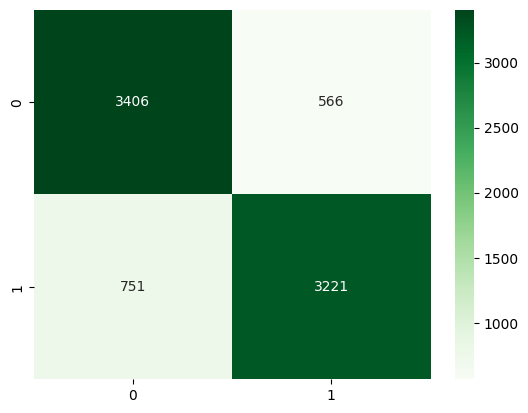

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      3972
           1       0.85      0.81      0.83      3972

    accuracy                           0.83      7944
   macro avg       0.83      0.83      0.83      7944
weighted avg       0.83      0.83      0.83      7944



In [20]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced'  # дополнительная балансировка
)

# Обучение модели
rf_model.fit(X_train_smote, y_train_smote)

# Предсказания на кросс-валидации
y_pred_selected = cross_val_predict(rf_model, X_train_smote, y_train_smote, cv=skf, n_jobs=-1)

print('Оценка на кросс-валидации:')
sns.heatmap(confusion_matrix(y_train_smote, y_pred_selected), annot=True, fmt='d',  cmap='Greens')
plt.show()
report_cv = classification_report(y_train_smote, y_pred_selected)
print(report_cv)

### 2.3 Feature engineering

In [21]:
features_data = pd.read_csv(current_dir.parent / "data" / "new_features.csv")

In [23]:
# Убираем лишнее
features_data = features_data.drop(['Unnamed: 0'], axis=1)
features_data = features_data[features_data['Status'] != 'CL']

# Разделение на признаки и таргет
X = features_data.drop('Status', axis=1)
y = features_data['Status']

# Кодирование таргета
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f'\nНовые классы: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')

# Разделение на train и test со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('')
print(f'Размер тренировочных данных: {X_train.shape}')
print(f'Размер тестовых данных: {X_test.shape}')


Новые классы: {'C': np.int64(0), 'D': np.int64(1)}

Размер тренировочных данных: (6104, 14)
Размер тестовых данных: (1526, 14)


In [24]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Создаем ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),  # числовые колонки оставляем как есть
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'  # удаляем все остальные колонки
)

# Обучаем на тренировочных данных
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)  # важно: transform, а не fit_transform!

Оценка на кросс-валидации:


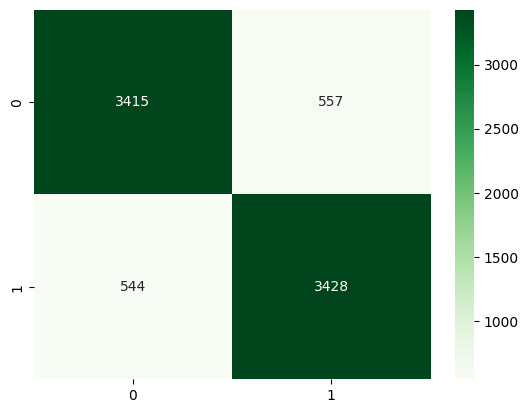

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      3972
           1       0.86      0.86      0.86      3972

    accuracy                           0.86      7944
   macro avg       0.86      0.86      0.86      7944
weighted avg       0.86      0.86      0.86      7944


Основные метрики:
ROC-AUC: 0.9328
Log-loss: 0.3349


In [25]:
# Создание объекта SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced'  # дополнительная балансировка
)

# Обучение модели
rf_model.fit(X_train_smote, y_train_smote)

# Предсказания на кросс-валидации
y_pred = cross_val_predict(rf_model, X_train_smote, y_train_smote, cv=skf, n_jobs=-1)
# Получаем вероятности
y_pred_proba = cross_val_predict(rf_model, X_train_smote, y_train_smote, cv=skf, method='predict_proba', n_jobs=-1)

print('Оценка на кросс-валидации:')
sns.heatmap(confusion_matrix(y_train_smote, y_pred), annot=True, fmt='d',  cmap='Greens')
plt.show()
report_cv = classification_report(y_train_smote, y_pred)
print(report_cv)

# Вычисляем метрики
roc_auc = roc_auc_score(y_train_smote, y_pred_proba[:, 1])
log_loss = log_loss(y_train_smote, y_pred_proba)

print(f"\nОсновные метрики:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Log-loss: {log_loss:.4f}")

## Отчет о проделанной работе

Нами были обучены следующие варианты моделей:
1. **Среди Дерева решений это**
- Baseline Decision Tree
- Decision Tree + перебор гиперпараметров GridSearch
- Decision Tree + перебор гиперпараметров GridSearch + удаление избыточних признаков (лучший вариант)
Причем 2ой и 3ий варианты показали примерно одинаковую оценку по метрикам

2. **Среди Случайного леса это**
- Baseline Random Forest со встроенной балансировкой классов (хорошие показатели log-loss и roc-auc, хороший Recall 1го класса и плохой 2го)
- Random Forest ссо строенной балансировкой + перебор гиперпараметров Optuna (очень хорошие показатели, улучшился Recall 2го класса до 0.80)
- Random Forest + перебор гиперпараметров Optuna + балансировка SMOTE (показатели хорошие, Recall 2го класса упал до 0.71)
- Random Forest с лучшими параметрами + удаление избыточных признаков (показатели заметно ухудшились)
- Random Forest + Feature engineering + балансировка SMOTE и встроенная (лучшие показатели)


## Выводы по моделям на основе деревьев

Лучшим вариантом модели стал **Random Forest + балансировка SMOTE и встроенная балансировка + Feature engineering**

In [26]:
print('Параметры Random Forest:')
print(rf_model.get_params)
print('')
print('Основные метрики')
print(report_cv)
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Log-loss: {log_loss:.4f}')

Параметры Random Forest:
<bound method BaseEstimator.get_params of RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=3, min_samples_split=5,
                       n_estimators=500, random_state=42)>

Основные метрики
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      3972
           1       0.86      0.86      0.86      3972

    accuracy                           0.86      7944
   macro avg       0.86      0.86      0.86      7944
weighted avg       0.86      0.86      0.86      7944

ROC-AUC: 0.9328
Log-loss: 0.3349


Стабильный для обоих классов Recall, минимальный из возможных среди других вариантов моделей los-loss и самый высокий из всех roc-auc.